# 2. Sequence Creation

Transforms tabular network flows into **temporal sequences** for transformer input.

## Approach
1. Sort flows by timestamp within each protocol group.
2. Create sliding windows of 64 consecutive flows with 50% overlap (stride = 32).
3. Assign sequence-level labels via **majority vote**.
4. Extract protocol and temporal position sequences alongside features.

In [23]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

from src.dataset import (
    create_flow_based_sequences,
    create_binary_labels,
    create_anomaly_scores,
)

print('Imports complete.')

Imports complete.


## 2.1 Load Preprocessed Data

In [24]:
DATA_DIR = '../data'

X_train = pd.read_csv(f'{DATA_DIR}/preprocessed_train_X.csv')
y_train = pd.read_csv(f'{DATA_DIR}/preprocessed_train_y.csv').squeeze()
X_test  = pd.read_csv(f'{DATA_DIR}/preprocessed_test_X.csv')
y_test  = pd.read_csv(f'{DATA_DIR}/preprocessed_test_y.csv').squeeze()

X_train.columns = X_train.columns.str.strip()
X_test.columns  = X_test.columns.str.strip()

for col in ['SimillarHTTP', 'SimilarHTTP']:
    if col in X_train.columns:
        X_train.drop(columns=[col], inplace=True)
        X_test.drop(columns=[col], inplace=True)

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc  = label_encoder.transform(y_test)
num_classes  = len(label_encoder.classes_)

print(f'Classes: {num_classes}')
print(f'Train flows: {X_train.shape[0]:,} | Test flows: {X_test.shape[0]:,}')

Classes: 13
Train flows: 97,807 | Test flows: 24,452


## 2.2 Create Sequences

In [25]:
SEQ_LEN = 64

print('=== Training Sequences ===')
X_seq_train, y_seq_train, proto_train, temp_train = create_flow_based_sequences(
    X_train, y_train_enc, seq_len=SEQ_LEN
)

print('\n=== Test Sequences ===')
X_seq_test, y_seq_test, proto_test, temp_test = create_flow_based_sequences(
    X_test, y_test_enc, seq_len=SEQ_LEN
)

feature_dim = X_seq_train.shape[-1]

print(f'\n--- Summary ---')
print(f'Train sequences : {X_seq_train.shape}')
print(f'Test sequences  : {X_seq_test.shape}')
print(f'Feature dim     : {feature_dim}')
print(f'Train label dist: {np.bincount(y_seq_train)}')
print(f'Test  label dist: {np.bincount(y_seq_test)}')

=== Training Sequences ===

=== Test Sequences ===

--- Summary ---
Train sequences : (3052, 64, 43)
Test sequences  : (760, 64, 43)
Feature dim     : 43
Train label dist: [941 174 188 175 176 175 175 176 172 176 174 175 175]
Test  label dist: [232  45  48  44  44  43  44  44  42  43  43  44  44]


## 2.3 Create Multi-Task Labels

In [26]:
y_bin_train = create_binary_labels(y_seq_train, label_encoder)
y_bin_test  = create_binary_labels(y_seq_test, label_encoder)

y_anom_train = create_anomaly_scores(y_seq_train, label_encoder)
y_anom_test  = create_anomaly_scores(y_seq_test, label_encoder)

print(f'Binary — Train: Normal={np.sum(y_bin_train==0)}, Attack={np.sum(y_bin_train==1)}')
print(f'Binary — Test : Normal={np.sum(y_bin_test==0)},  Attack={np.sum(y_bin_test==1)}')
print(f'Anomaly score range: [{y_anom_train.min():.2f}, {y_anom_train.max():.2f}]')

Binary — Train: Normal=941, Attack=2111
Binary — Test : Normal=232,  Attack=528
Anomaly score range: [0.00, 0.90]


## 2.4 Visualise Sequences

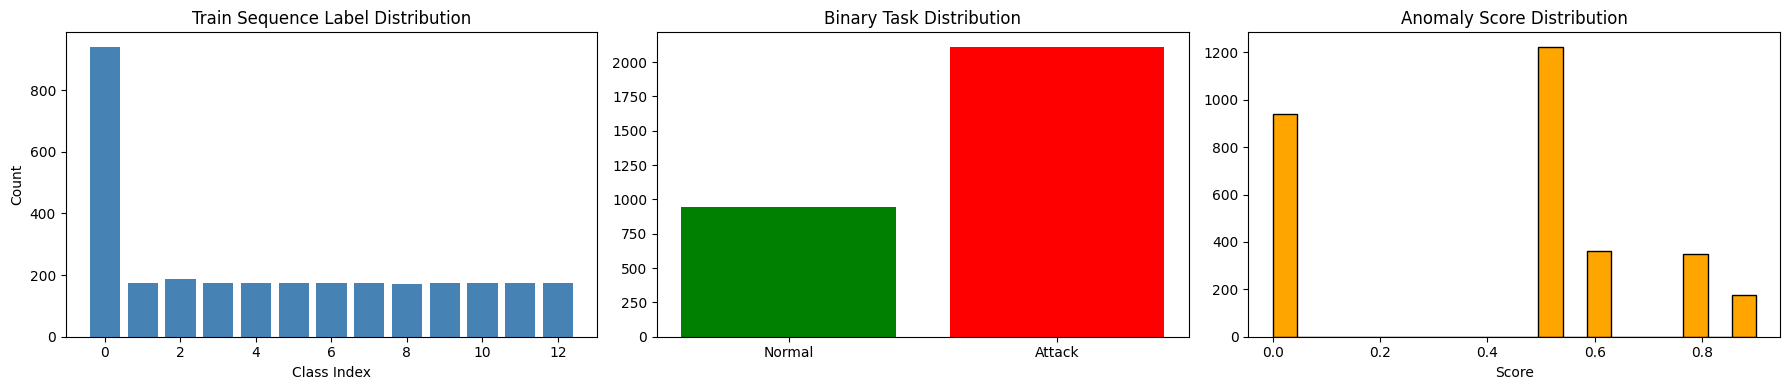

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Sequence label distribution
axes[0].bar(range(num_classes), np.bincount(y_seq_train, minlength=num_classes), color='steelblue')
axes[0].set_title('Train Sequence Label Distribution')
axes[0].set_xlabel('Class Index')
axes[0].set_ylabel('Count')

# Binary distribution
axes[1].bar(['Normal', 'Attack'],
            [np.sum(y_bin_train == 0), np.sum(y_bin_train == 1)],
            color=['green', 'red'])
axes[1].set_title('Binary Task Distribution')

# Anomaly score histogram
axes[2].hist(y_anom_train, bins=20, color='orange', edgecolor='black')
axes[2].set_title('Anomaly Score Distribution')
axes[2].set_xlabel('Score')

plt.tight_layout()
plt.savefig('../results/figures/sequence_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

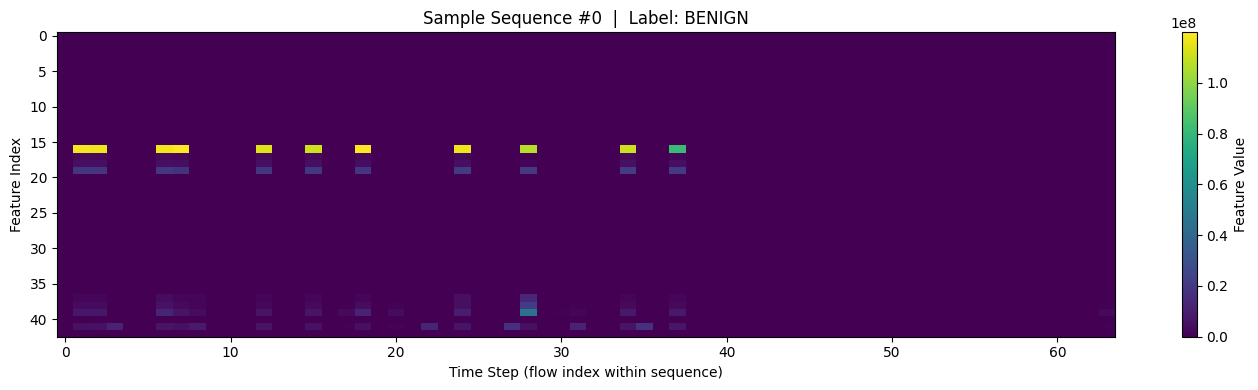

In [28]:
# Visualise a single sequence (heatmap of features across 64 time steps)
sample_idx = 0
sample = X_seq_train[sample_idx]  # shape: (64, feature_dim)

plt.figure(figsize=(14, 4))
plt.imshow(sample.T, aspect='auto', cmap='viridis')
plt.colorbar(label='Feature Value')
plt.xlabel('Time Step (flow index within sequence)')
plt.ylabel('Feature Index')
plt.title(f'Sample Sequence #{sample_idx}  |  Label: {label_encoder.classes_[y_seq_train[sample_idx]]}')
plt.tight_layout()
plt.show()

## 2.5 Save Sequences (Optional)

Uncomment the cell below to save sequences for faster loading in subsequent
notebooks.  The files are fairly small (~3k sequences).

In [29]:
np.savez_compressed(
    '../data/sequences.npz',
    X_train=X_seq_train, y_train=y_seq_train,
    proto_train=proto_train, temp_train=temp_train,
    X_test=X_seq_test, y_test=y_seq_test,
    proto_test=proto_test, temp_test=temp_test,
    y_bin_train=y_bin_train, y_bin_test=y_bin_test,
    y_anom_train=y_anom_train, y_anom_test=y_anom_test,
)
print('Saved to ../data/sequences.npz')

Saved to ../data/sequences.npz


## Summary

| Property | Details |
|---|---|
| Sequence length | 64 flows |
| Stride | 32 (50% overlap) |
| Grouping | By protocol type |
| Label strategy | Majority vote |
| Feature dim | 43 |
| Train sequences | ~3,052 |
| Test sequences | ~760 |

**Next step → [03_attention_exploration.ipynb](03_attention_exploration.ipynb):** Train and compare 4 attention mechanisms.